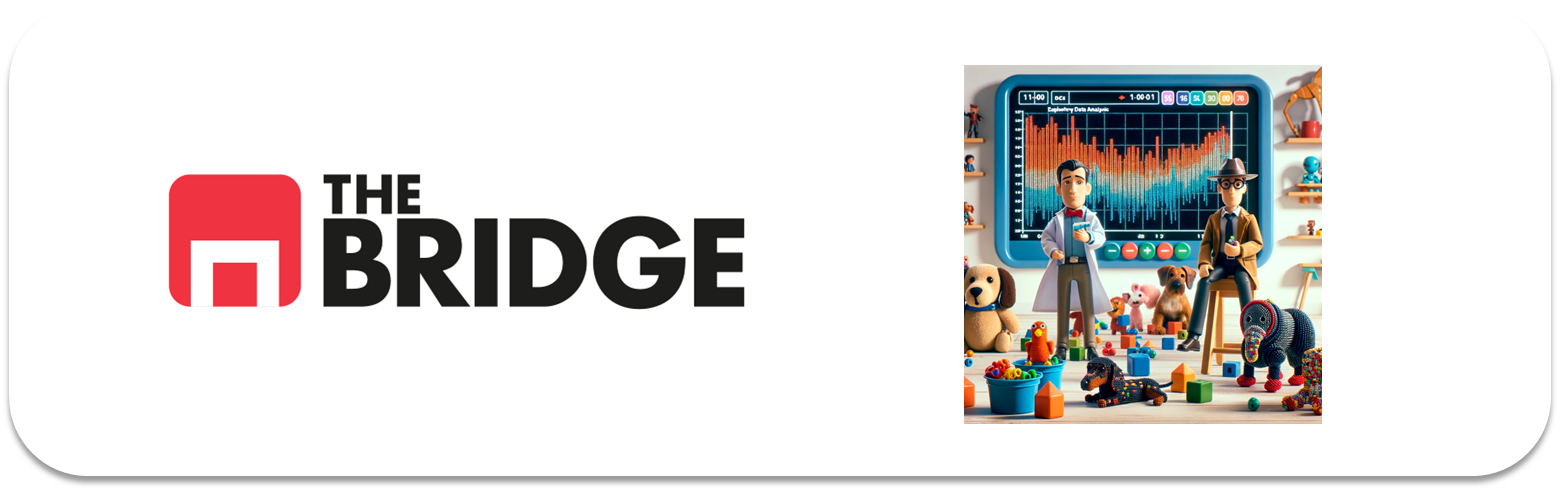

## PRACTICA OBLIGATORIA: **Análisis Multivariante**

* La práctica obligatoria de esta unidad consiste en completar el análisis del dataset del Titanic, dirigido por una serie de preguntas, y de terminar de analizar algunos aspectos del dataset de viajes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0


Importa los paquetes y módulos que necesites a lo largo del notebook

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## #1: Titanic

### #1.1

Carga en un dataframe el dataset del titanic, que está en la ruta "./data/titanic.csv".

In [2]:
df_titanic = pd.read_csv("./data/titanic.csv")

df_titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### #1.2

Deshazte de las columnas "deck", "survived", "pclass" y "embarked" porque no las emplearemos, la primera por su cantidad de nulos y el resto porque son variantes de otras que ya existen y cuyos valores resultan más expresivos a la hora de hacer un análisis. 

In [3]:

df_titanic = df_titanic.drop(columns=["deck", "survived", "pclass", "embarked"])
df_titanic.head()
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          891 non-null    object 
 1   age          714 non-null    float64
 2   sibsp        891 non-null    int64  
 3   parch        891 non-null    int64  
 4   fare         891 non-null    float64
 5   class        891 non-null    object 
 6   who          891 non-null    object 
 7   adult_male   891 non-null    bool   
 8   embark_town  889 non-null    object 
 9   alive        891 non-null    object 
 10  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(2), object(5)
memory usage: 64.5+ KB


### #1.3

Suma las columnas "parch" y "sibsp" para tener el número de parientes de cada pasajero, guarda el resultado en otra columna "family_members", luego deshazte de "parch" y "sibsp"

In [4]:
df_titanic["family_members"] = df_titanic["parch"] + df_titanic["sibsp"]

df_titanic = df_titanic.drop(columns=["parch", "sibsp"])


df_titanic.head()
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             891 non-null    object 
 1   age             714 non-null    float64
 2   fare            891 non-null    float64
 3   class           891 non-null    object 
 4   who             891 non-null    object 
 5   adult_male      891 non-null    bool   
 6   embark_town     889 non-null    object 
 7   alive           891 non-null    object 
 8   alone           891 non-null    bool   
 9   family_members  891 non-null    int64  
dtypes: bool(2), float64(2), int64(1), object(5)
memory usage: 57.6+ KB


### #1.4

Imputa la moda a los valores nulos de "embark_town"

In [5]:
moda_embark = df_titanic["embark_town"].mode()[0]

df_titanic["embark_town"] = df_titanic["embark_town"].fillna(moda_embark)
df_titanic["embark_town"].isna().sum()

np.int64(0)

### #1.5

Imputa la media a los valores faltantes de "age", si quieres puedes hacer algo más preciso (por ejemplo considerando además la columna "who")

In [6]:
df_titanic["age"] = df_titanic.groupby("who")["age"].transform(
    lambda x: x.fillna(x.mean())
)


df_titanic["age"].isna().sum()

np.int64(0)

### #1.6

Realiza los análisis bivariantes o multivariantes que necesites, así como los test de hipótesis necesarios para contestar a las siguientes preguntas. Nota: utiliza la variable "alive" para saber si un pasajero sobrevivió o no:

1. En términos absolutos, ¿sobrevivieron más hombres, mujeres o niños? ¿Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre el sexo y la supervivencia en el Titanic?¿Y entre ser adulto o ser niño?

2. En términos absolutos, ¿de que clase sobrevivieron más pasajeros?¿ Y en términos relativos? ¿Existe alguna relación estadísticamente significativa entre la clase en la que se viajaba y la supervivencia?

3. ¿De qué ciudad sobrevivieron más personas?¿Y porcentualmente de que ciudad sobrevivieron más personas? ¿Hay alguna relación estadística significativa entre haber embarcado en una de las tres ciudades y haber sobrevivido o fallecido?

4. ¿Qué relación hay entre el precio del pasaje y la supervivencia/fallecimiento?

5. Existen pasajero que no pagaron el billete, ¿podrías explicar por qué? ¿Qué ocurrió con la persona que más dinero se dejó?

6. Existe alguna relación entre el dinero pagado, la ciudad de embarque y la superviviencia/fallecimiento. No necesitas aplicar ningún test, muestralo numérica o visualmente.

7. Ahondando en la relación entre sobrevivir o fallecer, la clase en la que se viajó y la edad de los pasajeros. ¿Qué agrupación de las dos variables (clase y edad) sobrevivió más en términos absolutos y en términos relativos?

8. Finalmente, muestra las posibles relaciones entre edad, coste del billete y supervivencia/fallecimiento. ¿Qué puedes decir al respecto?

In [11]:
!pip install scipy

  Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.16.3-cp313-cp313-win_amd64.whl (38.5 MB)



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


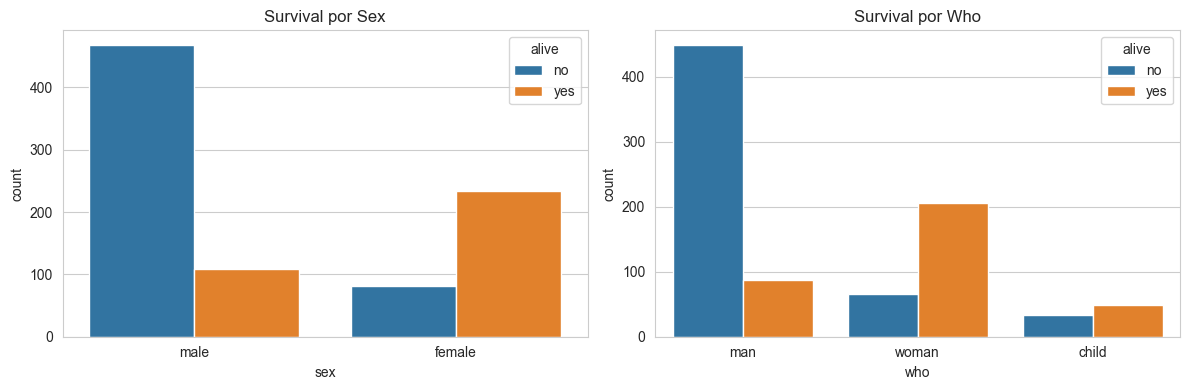

Chi² SEX vs ALIVE — p-value: 1.1973570627755645e-58
Chi² WHO vs ALIVE — p-value: 2.2227620817798914e-62


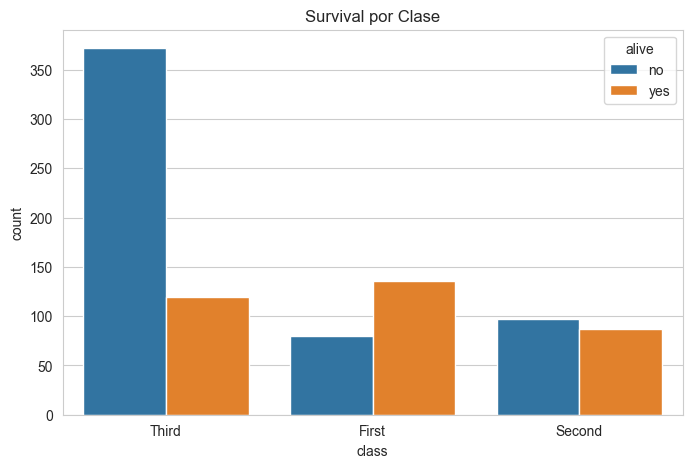

Chi² CLASS vs ALIVE — p-value: 4.549251711298793e-23


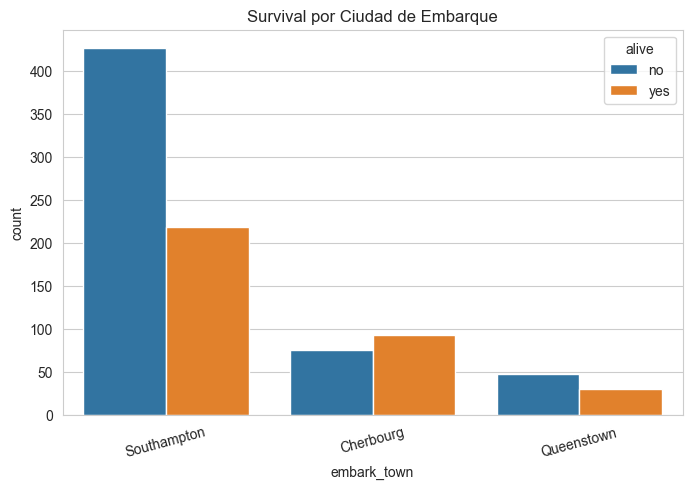

Chi² EMBARK_TOWN vs ALIVE — p-value: 2.3008626481449577e-06


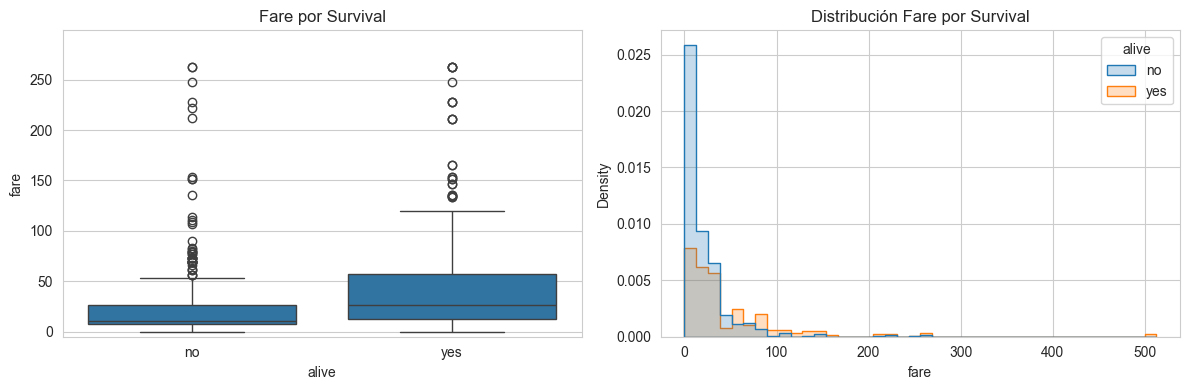

Mann–Whitney FARE yes/no — p-value: 4.553477179250237e-22
Pasajeros con fare=0: 15
Fare máximo: 512.3292
Top payer(s):


,class,alive,fare,sex,age,embark_town
258,First,yes,512.3292,female,35.0,Cherbourg
679,First,yes,512.3292,male,36.0,Cherbourg
737,First,yes,512.3292,male,35.0,Cherbourg


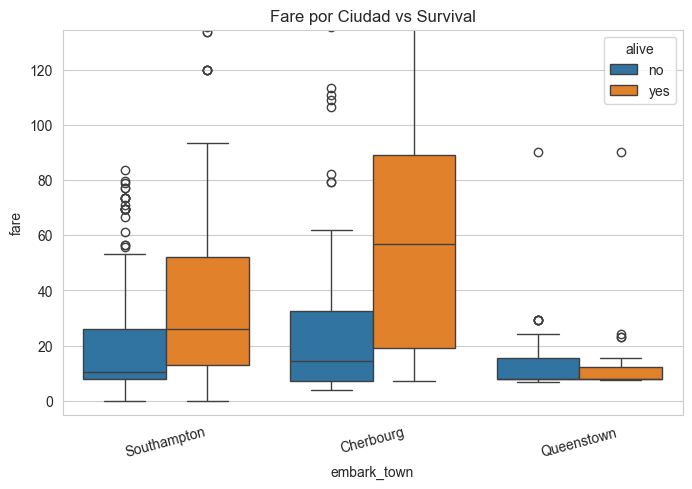

C:\Users\andre\AppData\Local\Temp\ipykernel_23228\58227831.py:112: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index="age_group",


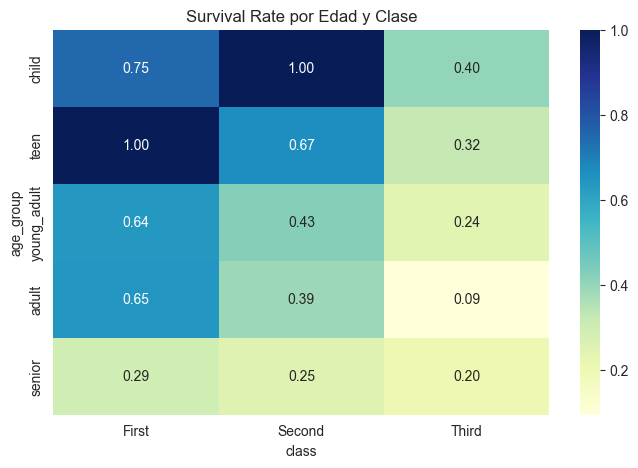

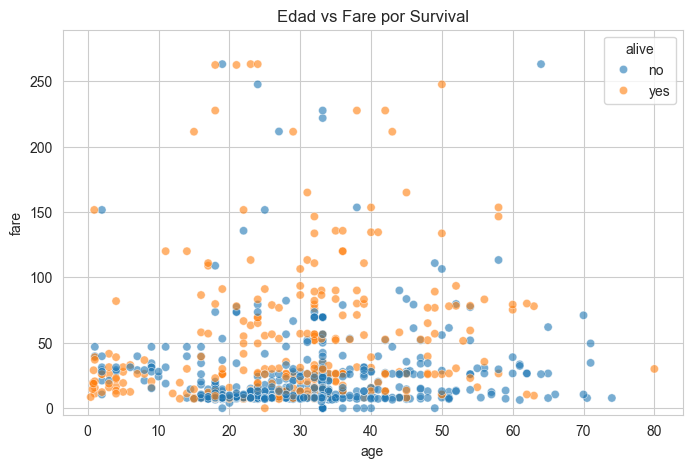

In [ ]:
# CARGA Y PREPARACIÓN

from scipy.stats import chi2_contingency, mannwhitneyu

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)



df = pd.read_csv("./data/titanic.csv")

df["alive_bin"] = df["alive"].map({"yes":1, "no":0})
df["family_members"] = df["parch"] + df["sibsp"]

df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])
df["age"] = df.groupby("who")["age"].transform(lambda x: x.fillna(x.mean()))


# 1) SEX y WHO vs survival (gráficas + chi2)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.countplot(data=df, x="sex", hue="alive")
plt.title("Survival por Sex")

plt.subplot(1,2,2)
sns.countplot(data=df, x="who", hue="alive")
plt.title("Survival por Who")
plt.tight_layout()
plt.show()

# Chi2 sex
ct = pd.crosstab(df["sex"], df["alive"])
chi2, p, _, _ = chi2_contingency(ct)
print("Chi² SEX vs ALIVE — p-value:", p)

# Chi2 who
ct = pd.crosstab(df["who"], df["alive"])
chi2, p, _, _ = chi2_contingency(ct)
print("Chi² WHO vs ALIVE — p-value:", p)


# 2) CLASS vs survival

plt.figure()
sns.countplot(data=df, x="class", hue="alive")
plt.title("Survival por Clase")
plt.show()

ct = pd.crosstab(df["class"], df["alive"])
chi2, p, _, _ = chi2_contingency(ct)
print("Chi² CLASS vs ALIVE — p-value:", p)


# 3) EMBARK TOWN vs survival

plt.figure()
sns.countplot(data=df, x="embark_town", hue="alive")
plt.title("Survival por Ciudad de Embarque")
plt.xticks(rotation=15)
plt.show()

ct = pd.crosstab(df["embark_town"], df["alive"])
chi2, p, _, _ = chi2_contingency(ct)
print("Chi² EMBARK_TOWN vs ALIVE — p-value:", p)


# 4) FARE vs survival (boxplot + Mann–Whitney)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
sns.boxplot(data=df, x="alive", y="fare")
plt.title("Fare por Survival")
plt.ylim(-5, df["fare"].quantile(0.99)*1.2)

plt.subplot(1,2,2)
sns.histplot(data=df, x="fare", hue="alive", bins=40, element="step", stat="density")
plt.title("Distribución Fare por Survival")
plt.tight_layout()
plt.show()

# Mann–Whitney
fare_yes = df[df["alive"]=="yes"]["fare"]
fare_no  = df[df["alive"]=="no"]["fare"]
u, p = mannwhitneyu(fare_yes, fare_no)
print("Mann–Whitney FARE yes/no — p-value:", p)


# 5) Fare = 0 y top payer

print("Pasajeros con fare=0:", len(df[df["fare"]==0]))
print("Fare máximo:", df["fare"].max())
print("Top payer(s):")
display(df[df["fare"]==df["fare"].max()][["class","alive","fare","sex","age","embark_town"]])


# 6) Fare + embark town + survival

plt.figure()
sns.boxplot(data=df, x="embark_town", y="fare", hue="alive")
plt.title("Fare por Ciudad vs Survival")
plt.xticks(rotation=15)
plt.ylim(-5, df["fare"].quantile(0.95)*1.2)
plt.show()


# 7) Clase + Edad agrupada vs survival (heatmap)

bins = [0,12,18,35,60,120]
labels = ["child","teen","young_adult","adult","senior"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

pivot = df.pivot_table(index="age_group",
                       columns="class",
                       values="alive_bin",
                       aggfunc="mean")

plt.figure()
sns.heatmap(pivot, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Survival Rate por Edad y Clase")
plt.show()


# 8) Age vs Fare vs Survival (scatter)

plt.figure()
sns.scatterplot(data=df, x="age", y="fare", hue="alive", alpha=.6)
plt.title("Edad vs Fare por Survival")
plt.ylim(-5, df["fare"].quantile(0.995)*1.1)
plt.show()


## #EXTRA: Viajes

El objetivo en este caso no es tanto hacer un montón de análisis sino de completar lo que quedó pendiente en el workout y de entender cómo de un dataset podemos obtener preguntas o hipótesis interesantes (si las hay)

### #EXTRA.1 

Carga el dataset de viajes del mes de junio. Repite el análisis bivariante entre las variables "Aircompany" e "Ingresos", mostrando previamente los viajes por compañía aérea. ¿Qué situación llamativa nos surgió? (Ten en cuenta que somos el departamenteo de DataScience de TabarAir)

,aircompany,origen,destino,distancia,avion,con_escala,consumo_kg,duracion,ingresos,id_vuelo,mes
0,Airnar,París,Ginebra,411,Boeing 737,False,1028.691900,51,14232.65,Air_PaGi_10737,Jun23
1,FlyQ,Bali,Roma,12738,Boeing 737,True,33479.132544,1167,468527.19,Fly_BaRo_10737,Jun23
2,TabarAir,Ginebra,Los Angeles,9103,Airbus A380,False,109439.907200,626,584789.19,Tab_GiLo_11380,Jun23
3,MoldaviAir,París,Cincinnati,6370,Boeing 737,False,17027.010000,503,233342.51,Mol_PaCi_10737,Jun23
4,TabarAir,Cincinnati,Roma,7480,Boeing 747,False,86115.744000,518,438535.07,Tab_CiRo_10747,Jun23


Número de vuelos por compañía:


aircompany
TabarAir      142
MoldaviAir    133
PamPangea     117
FlyQ          108
Airnar        100
Name: count, dtype: int64

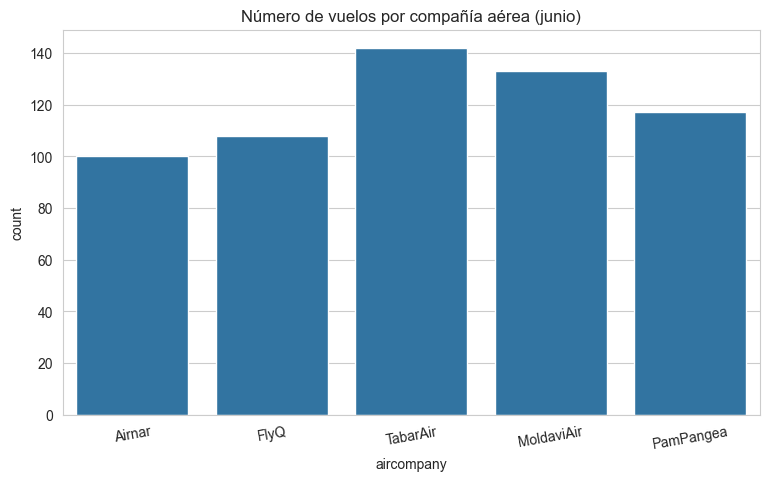

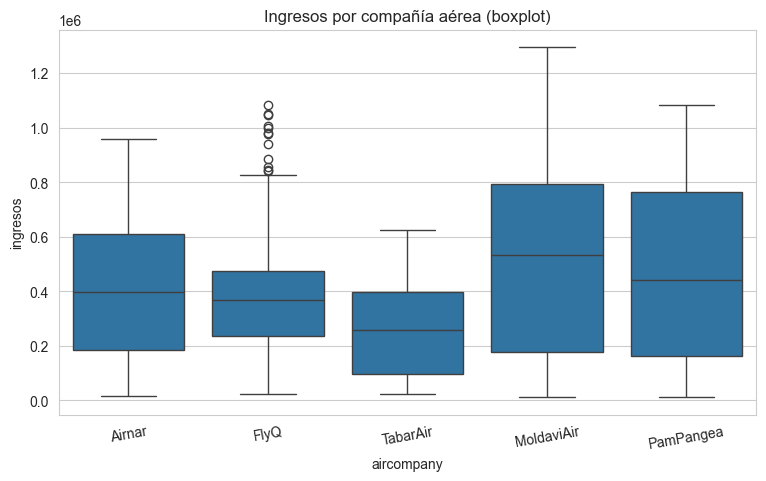

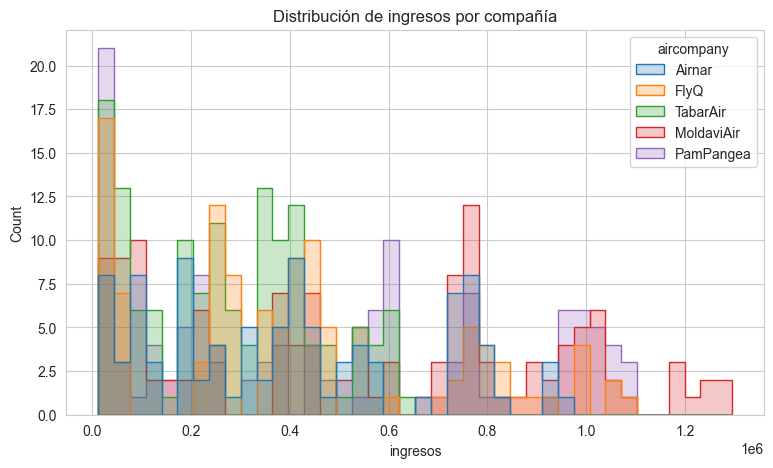

ANOVA ingresos por compañía
F = 15.686872918809376
p-value = 3.267745855663723e-12


In [16]:
# 1. Cargar dataset
from scipy.stats import f_oneway  

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9,5)

df_jun = pd.read_csv("./data/dataset_viajes_jun.csv")
display(df_jun.head())


# 2. Viajes por compañía aérea

print("Número de vuelos por compañía:")
display(df_jun["aircompany"].value_counts())

plt.figure()
sns.countplot(data=df_jun, x="aircompany")
plt.title("Número de vuelos por compañía aérea (junio)")
plt.xticks(rotation=10)
plt.show()


# 3. Relación Aircompany – Ingresos

plt.figure()
sns.boxplot(data=df_jun, x="aircompany", y="ingresos")
plt.title("Ingresos por compañía aérea (boxplot)")
plt.xticks(rotation=10)
plt.show()

# Distribuciones (histogramas agrupados)
plt.figure()
sns.histplot(data=df_jun, x="ingresos", hue="aircompany", kde=False, element="step", bins=40)
plt.title("Distribución de ingresos por compañía")
plt.show()


# 4. ANOVA – Ingresos entre compañías

groups = [df_jun[df_jun["aircompany"]==company]["ingresos"]
          for company in df_jun["aircompany"].unique()]

f_stat, p_value = f_oneway(*groups)

print("ANOVA ingresos por compañía")
print("F =", f_stat)
print("p-value =", p_value)

### #EXTRA.2

Repite el análisis multivariante entre "ingresos","distancias" y "consumo_kg". ¿Qué veíamos que parecía también muy prometedor?

### #EXTRA.3

Crea una variable categorica "cat_vuelo" a partir de distancias, escoge los rangos de las categorías basándote en la distribución de valores de "distancia" (sugerencia entre 3 y 4 categorías). Extra: Reaiza ahora otra vez el análisis multivariante "cat_vuelo", "ingresos", "consumo_kg". ¿Ves algo diferente?